# Data Cleaning

In [17]:
import pandas as pd
import numpy as np

n_lines = 7700000  # 대략적인 전체 행 수
sample_size = 500000 # 분석에 사용할 행 수

skip_indices = np.random.choice(
    np.arange(1, n_lines),
    size=n_lines - 1 - sample_size,
    replace=False
)

df = pd.read_csv('../data/US_Accidents_March23.csv', skiprows=skip_indices)
print(df['State'].value_counts().head(10))


State
CA    118618
FL     58738
TX     38993
SC     25099
NY     23341
NC     22203
VA     20410
PA     19374
OR     17022
MN     12720
Name: count, dtype: int64


In [18]:
# 결측치 비율 확인 (null 값) 및 무의미한 속성 제거
missing_percentages = df.isna().mean().sort_values(ascending=False) * 100

cols_to_drop = missing_percentages[missing_percentages > 90].index.tolist()
print(f"제거될 칼럼 (결측치 > 90%) :  {cols_to_drop}")

df = df.drop(columns=cols_to_drop)

제거될 칼럼 (결측치 > 90%) :  []


In [19]:
# 핵심 정보가 없는 행 제거
import_columns = ['City', 'Weather_Condition', 'Start_Time', 'Street']
df = df.dropna(subset=import_columns)

# EDA by timing and weather

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시간 데이터 추출
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Hour'] = df['Start_Time'].dt.hour
df['Year'] = df['Start_Time'].dt.year

C:\Users\selfi\AppData\Local\Temp\ipykernel_22104\2431310688.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='viridis')


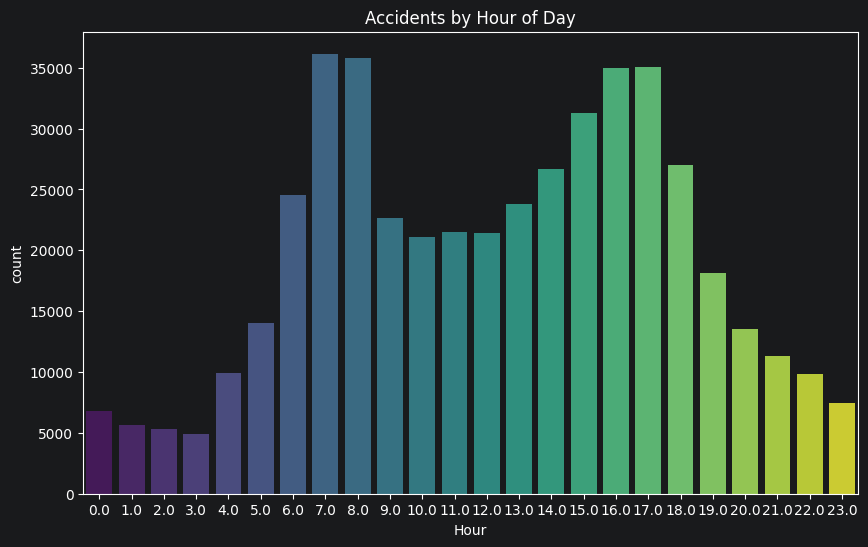

In [21]:
# 2. 시간대별 사고 건수 시각화
plt.figure(figsize=(10, 6))
sns.countplot(x='Hour', data=df, palette='viridis')
plt.title('Accidents by Hour of Day')
plt.show()

C:\Users\selfi\AppData\Local\Temp\ipykernel_22104\570612924.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_severity['mean'].head(15), y=weather_severity.index[:15], palette='coolwarm')


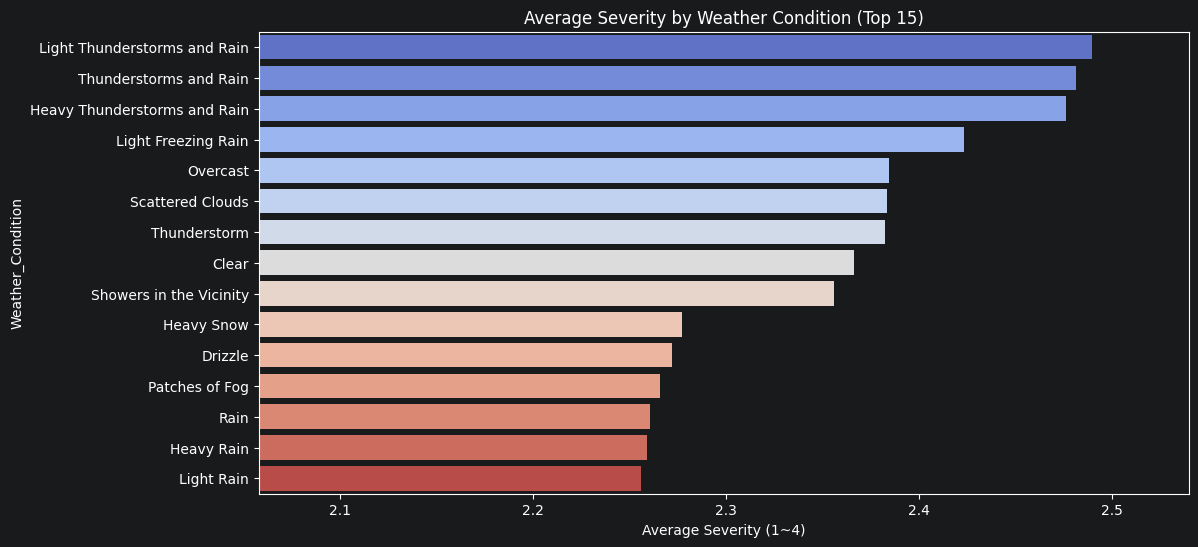

In [22]:
# 3. 날씨별 사고 수준
weather_severity = df.groupby('Weather_Condition')['Severity'].agg(['mean', 'count'])
weather_severity = weather_severity[weather_severity['count'] > 100].sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=weather_severity['mean'].head(15), y=weather_severity.index[:15], palette='coolwarm')
plt.xlim(weather_severity['mean'].min() - 0.05, weather_severity['mean'].max() + 0.05)
plt.title('Average Severity by Weather Condition (Top 15)')
plt.xlabel('Average Severity (1~4)')
plt.show()

C:\Users\selfi\AppData\Local\Temp\ipykernel_22104\2406190154.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=severe_ratio.values, y=severe_ratio.index, palette='Reds_r')


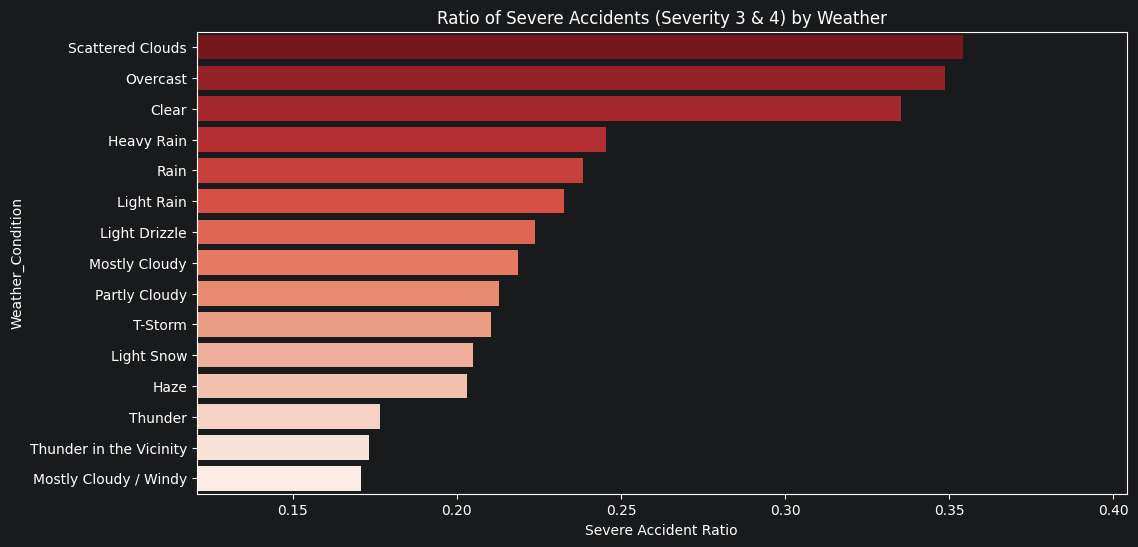

In [23]:
# 4. 날씨별 심각도 3 이상의 사고 비율 계산
weather_counts = df['Weather_Condition'].value_counts()
reliable_weathers = weather_counts[weather_counts >= 1000].index

df['Is_Severe'] = df['Severity'] >= 3
severe_ratio = df[df['Weather_Condition'].isin(reliable_weathers)].groupby('Weather_Condition')['Is_Severe'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=severe_ratio.values, y=severe_ratio.index, palette='Reds_r')
plt.xlim(severe_ratio.min() - 0.05, severe_ratio.max() + 0.05)
plt.title('Ratio of Severe Accidents (Severity 3 & 4) by Weather')
plt.xlabel('Severe Accident Ratio')
plt.show()

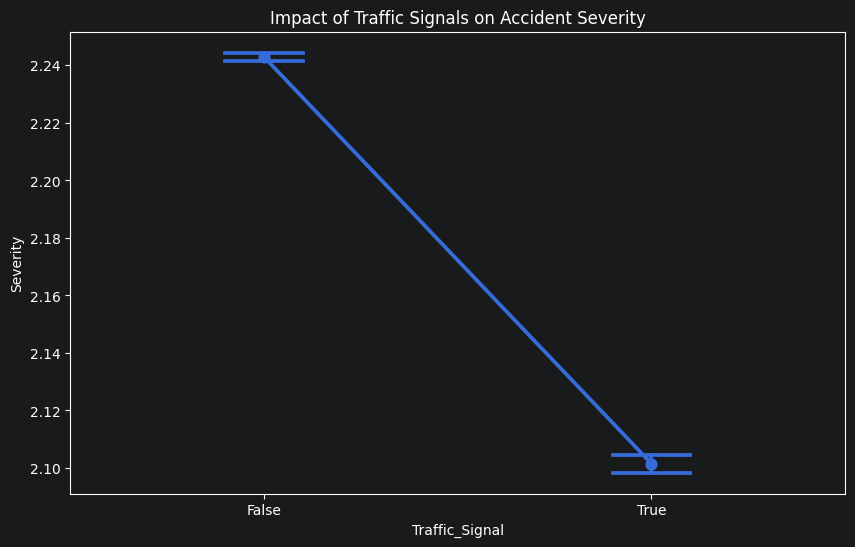

In [24]:
# 5. 도로 시설물(Traffic Signal)이 사고 심각도에 주는 영향
plt.figure(figsize=(10, 6))
sns.pointplot(data=df, x='Traffic_Signal', y='Severity', capsize=.2)
plt.title('Impact of Traffic Signals on Accident Severity')
plt.show()

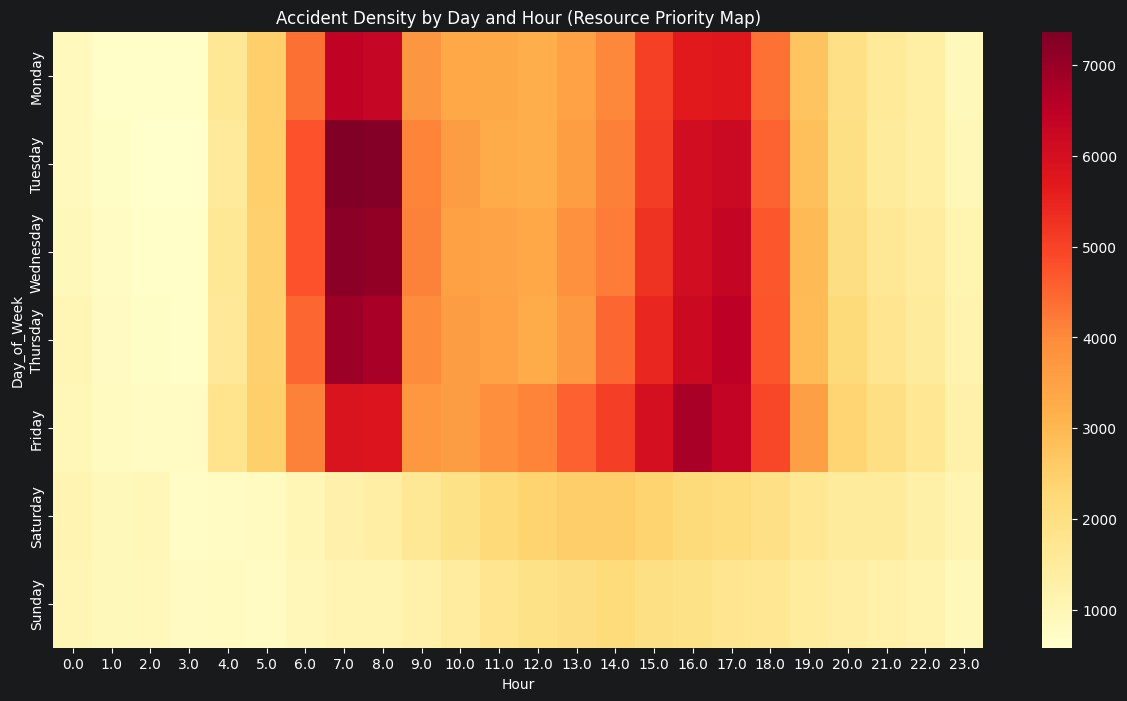

In [25]:
# 사고가 많이 일어나는 시간 히트맵
df['Day_of_Week'] = df['Start_Time'].dt.day_name()
df['Hour'] = df['Start_Time'].dt.hour

pivot_table = df.pivot_table(index='Day_of_Week', columns='Hour', values='Severity', aggfunc='count')
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = pivot_table.reindex(days)

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, cmap='YlOrRd', annot=False)
plt.title('Accident Density by Day and Hour (Resource Priority Map)')
plt.show()

# EDA by geography

In [26]:
state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Accident_Count']

In [27]:
import plotly.express as px

# 주별 사고 건수와 평균 심각도 계산
state_stats = df.groupby('State').agg({
    'ID': 'count',
    'Severity': 'mean'
}).rename(columns={'ID': 'Count'}).reset_index()

# 지도 시각화 (Choropleth Map)
fig = px.choropleth(state_stats,
                    locations='State',
                    locationmode="USA-states",
                    color='Count', # 혹은 'Severity'로 변경해서 확인
                    scope="usa",
                    title='Total Accidents by State',
                    color_continuous_scale="Reds")

fig.show()

In [28]:
print(df['State'].unique())
state_counts = df['State'].value_counts()
print("데이터에 포함된 주 목록:\n", state_counts)


['OH' 'CA' 'FL' 'GA' 'SC' 'NE' 'IA' 'MO' 'IL' 'WI' 'IN' 'MI' 'MA' 'NY'
 'NJ' 'CT' 'RI' 'NH' 'MD' 'PA' 'VA' 'DC' 'DE' 'WV' 'TX' 'WA' 'OR' 'MN'
 'AL' 'OK' 'LA' 'AZ' 'UT' 'NC' 'NM' 'KS' 'TN' 'KY' 'CO' 'ME' 'NV' 'AR'
 'MS' 'VT' 'MT' 'ID' 'WY' 'SD' 'ND']
데이터에 포함된 주 목록:
 State
CA    115709
FL     58000
TX     38380
SC     24625
NY     23139
NC     21854
VA     19152
PA     18950
OR     16699
MN     12522
IL     11855
GA     11516
TN     11162
MI     11125
AZ     11004
LA      9725
NJ      9519
UT      7901
WA      7870
MD      7682
OH      7537
CO      6696
AL      6529
OK      5494
MO      5071
CT      4723
IN      4466
MA      3923
WI      2420
KY      2213
NE      1940
MT      1798
IA      1743
AR      1596
NV      1431
KS      1227
DC      1186
RI      1155
MS      1018
DE       970
WV       952
NH       796
ID       759
NM       671
ME       286
WY       249
ND       198
VT        78
SD        22
Name: count, dtype: int64


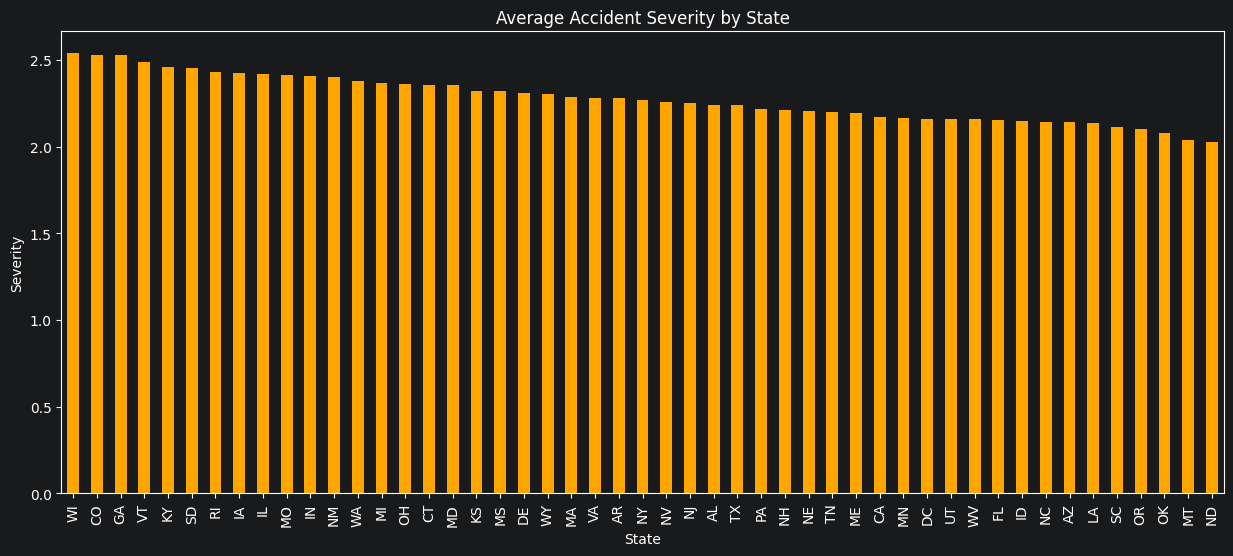

In [29]:
# 주별 평균 심각도 계산
state_severity = df.groupby('State')['Severity'].mean().sort_values(ascending=False)

# 시각화
plt.figure(figsize=(15, 6))
state_severity.plot(kind='bar', color='orange')
plt.title('Average Accident Severity by State')
plt.ylabel('Severity')
plt.show()

In [31]:
df['Is_Highway'] = df['Street'].str.contains('I-|Hwy|US-', case=False, na=False)

# 2. 주별 고속도로 사고 비중 및 평균 심각도 집계
state_hwy_stats = df.groupby('State').agg({
    'Is_Highway': 'mean',      # 고속도로 사고 비율
    'Severity': 'mean',        # 평균 심각도
    'ID': 'count'              # 전체 건수
}).rename(columns={'Is_Highway': 'Highway_Ratio', 'ID': 'Total_Count'}).reset_index()

# 3. 고속도로 비중 지도 시각화 (Choropleth)
import plotly.express as px

fig = px.choropleth(state_hwy_stats,
                    locations='State',
                    locationmode="USA-states",
                    color='Highway_Ratio',
                    scope="usa",
                    title='Percentage of Highway Accidents by State',
                    labels={'Highway_Ratio': 'Highway Accident %'},
                    color_continuous_scale="YlGnBu")
fig.show()